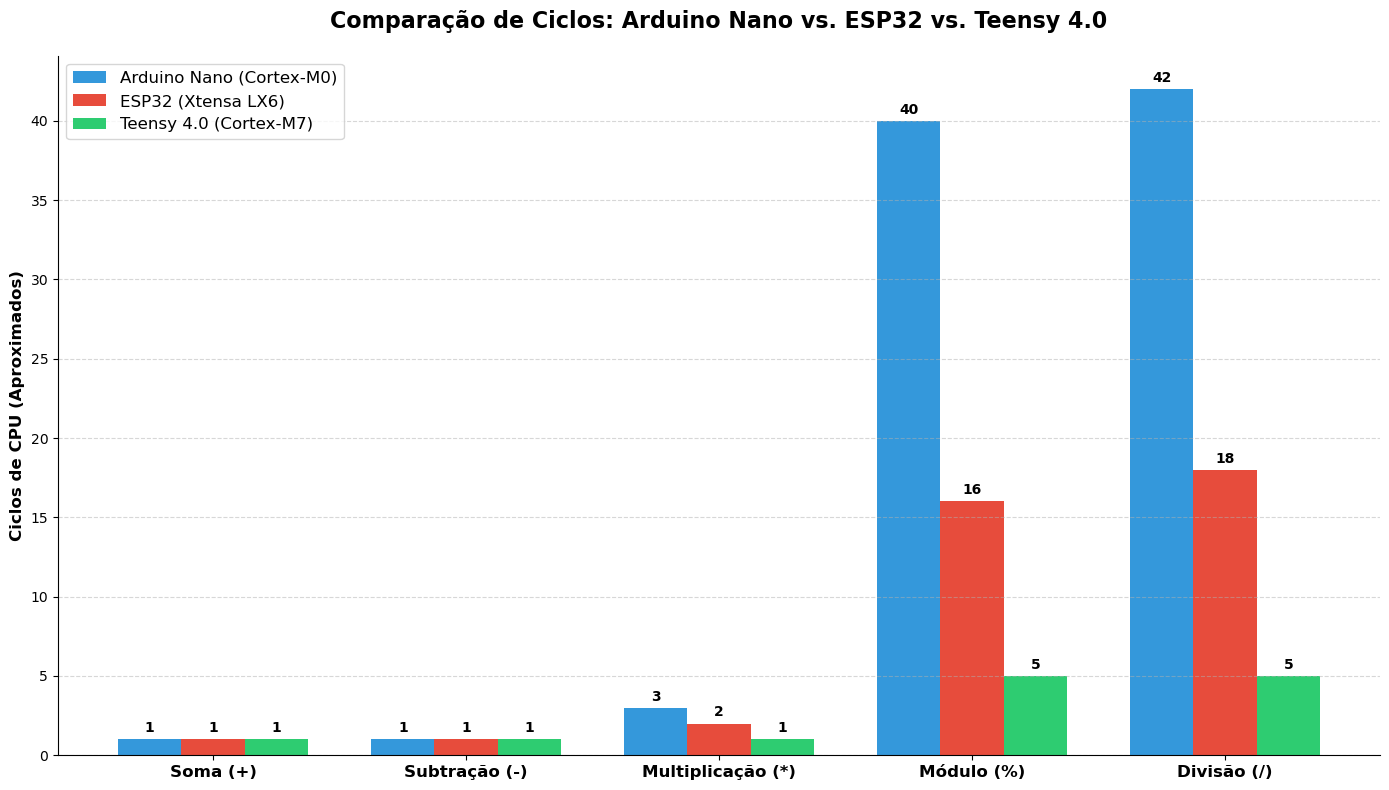

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Dados das operações
operacoes = ['Soma (+)', 'Subtração (-)', 'Multiplicação (*)', 'Módulo (%)', 'Divisão (/)']

# Ciclos de CPU aproximados
ciclos_nano = [1, 1, 3, 40, 42]
ciclos_esp32 = [1, 1, 2, 16, 18]
# Cortex-M7 tem divisão por hardware superescalar (2 a 12 ciclos) e multiplicação em 1 ciclo
ciclos_teensy = [1, 1, 1, 5, 5] 

# Posições no eixo X
x = np.arange(len(operacoes))
largura = 0.25  # Largura das barras ajustada para caberem 3 colunas

# Criando o gráfico
fig, ax = plt.subplots(figsize=(14, 8), facecolor='white')
ax.set_facecolor('white')

# Desenhando as barras
barras_nano = ax.bar(x - largura, ciclos_nano, largura, label='Arduino Nano (Cortex-M0)', color='#3498db')
barras_esp32 = ax.bar(x, ciclos_esp32, largura, label='ESP32 (Xtensa LX6)', color='#e74c3c')
barras_teensy = ax.bar(x + largura, ciclos_teensy, largura, label='Teensy 4.0 (Cortex-M7)', color='#2ecc71')

# Configurando os textos e rótulos
ax.set_ylabel('Ciclos de CPU (Aproximados)', fontsize=12, fontweight='bold')
ax.set_title('Comparação de Ciclos: Arduino Nano vs. ESP32 vs. Teensy 4.0', fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(operacoes, fontsize=12, fontweight='bold')
ax.legend(fontsize=12)

# Adicionando os valores em cima de cada barra
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 pontos de margem vertical
                    textcoords="offset points",
                    ha='center', va='bottom', fontweight='bold', fontsize=10)

autolabel(barras_nano)
autolabel(barras_esp32)
autolabel(barras_teensy)

# Estilização: removendo bordas desnecessárias
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('comparativo_ciclos_teensy.png', facecolor='white', bbox_inches='tight')